In [1]:
# Nombres de los integrantes:
# 1.Julian Gomez Posada
# 2.Laura Posada
# 3.Samuel Gil lopez

# Dataset seleccionado: shopping_behavior_updated
# https://www.kaggle.com/datasets/saadaliyaseen/shopping-behaviour-dataset?resource=download
# Problema que desean resolver:
#¿Podríamos predecir si aplicara descuento en la compra basándonos en sus características o en compras anteriores?

# Tipo de problema (clasificación):
#Regresion

In [25]:
# Importa aquí las librerías necesarias.
# Ejemplo:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix,roc_curve, auc)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import seaborn as sns

# Importamos una función para generar un dataset no lineal.
from sklearn.datasets import make_moons

# Importamos el clasificador SVM.
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [2]:
# Carga aquí tu dataset.
# Ejemplo:
df = pd.read_csv("/content/shopping_behavior_updated (1).csv")

print("Primeras filas:")
print(df.head(5))
print()

print("Ultimas filas:")
print(df.tail(3))
print()


Primeras filas:
   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
0            1   55   Male         Blouse  Clothing                     53   
1            2   19   Male        Sweater  Clothing                     64   
2            3   50   Male          Jeans  Clothing                     73   
3            4   21   Male        Sandals  Footwear                     90   
4            5   45   Male         Blouse  Clothing                     49   

        Location Size      Color  Season  Review Rating Subscription Status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   Shipping Type Discount Applied Promo 

### Interpretación

Describe brevemente:
- qué contiene el dataset:
    El conjunto de datos registra el comportamiento de compra de los clientes en función de diferentes características demográficas y atributos de compra.
    Incluye información sobre los artículos comprados, el gasto, los antecedentes del cliente y sus preferencias de compra.
    Los datos ayudan a analizar las tendencias de consumo, los patrones de compra y el comportamiento estacional.
    
- cuántas filas y columnas tiene:
    El dataset tiene un total de 3900 filas y 18 columnas

- qué representa cada registro: Cada registro en la base de datos representa  una compra realizada

1. ID de cliente : identificador único para cada cliente.

2. Edad: Edad del cliente en años.

3. Género : Indica si el cliente es masculino o femenino.

4. Artículo comprado : El producto específico que compró el cliente.

5. Categoría: Categoría de producto como ropa, calzado, etc.

6. Importe de la compra (USD) : importe total gastado en dólares estadounidenses.

7. Ubicación : Indique dónde realizó la compra el cliente.

8. Talla: Talla de la prenda/calzado comprado.

9. Color: Color del artículo comprado.

10. Temporada: Temporada en la que se realizó la compra.

11. Calificación de la reseña : Calificación numérica que el cliente otorga a su experiencia de compra.

12. Estado de la suscripción : indica si el cliente está suscrito (Sí/No).

13. Tipo de envío : método utilizado para enviar el pedido.

14. Descuento aplicado : si se aplicó algún descuento.

15. Código promocional utilizado : Indica si se aplicó algún código promocional.

16. Compras anteriores : número de compras históricas realizadas por el cliente.

17. Método de pago : modo de pago utilizado para la transacción.

18. Frecuencia de compra : con qué frecuencia el cliente realiza compras.




In [3]:
print("Dimensiones (filas, columnas):", df.shape)
print("Columnas:", list(df.columns))
print()

print("Tipos de datos y nulos:")
print(df.info())
print()

print("Valores nulos por columna:")
print(df.isnull().sum())
print()

print("Resumen numerico (media, desv, min, max, cuartiles) excluyendo 'Customer ID':")
print(df.drop(columns=['Customer ID']).describe())
print()

print("Resumen de categorias (valores unicos, frecuencia) para columnas object:")
display(df.describe(include='object'))
print()

print("Categorias de producto (valores unicos):")
print(df['Category'].unique())
print()

print("Items comprados (valores unicos):")
print(df['Item Purchased'].unique())
print()

print("Localizaciones (valores unicos):")
print(df['Location'].unique())
print()

print("Tallas (valores unicos):")
print(df['Size'].unique())
print()

print("Colores (valores unicos):")
print(df['Color'].unique())
print()

print("Temporadas (valores unicos):")
print(df['Season'].unique())
print()

print("Metodos de pago (valores unicos):")
print(df['Payment Method'].unique())
print()

print("Frecuencia de compra (valores unicos):")
print(df['Frequency of Purchases'].unique())
print()

#visualizar la distrubucion
print("Distribucion de las variables categoricas:")



Dimensiones (filas, columnas): (3900, 18)
Columnas: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']

Tipos de datos y nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   objec

,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,675,2223,2223,677,584



Categorias de producto (valores unicos):
['Clothing' 'Footwear' 'Outerwear' 'Accessories']

Items comprados (valores unicos):
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']

Localizaciones (valores unicos):
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington' 'Wisconsin' 'Michigan']

Tallas (valores unicos):
['L'

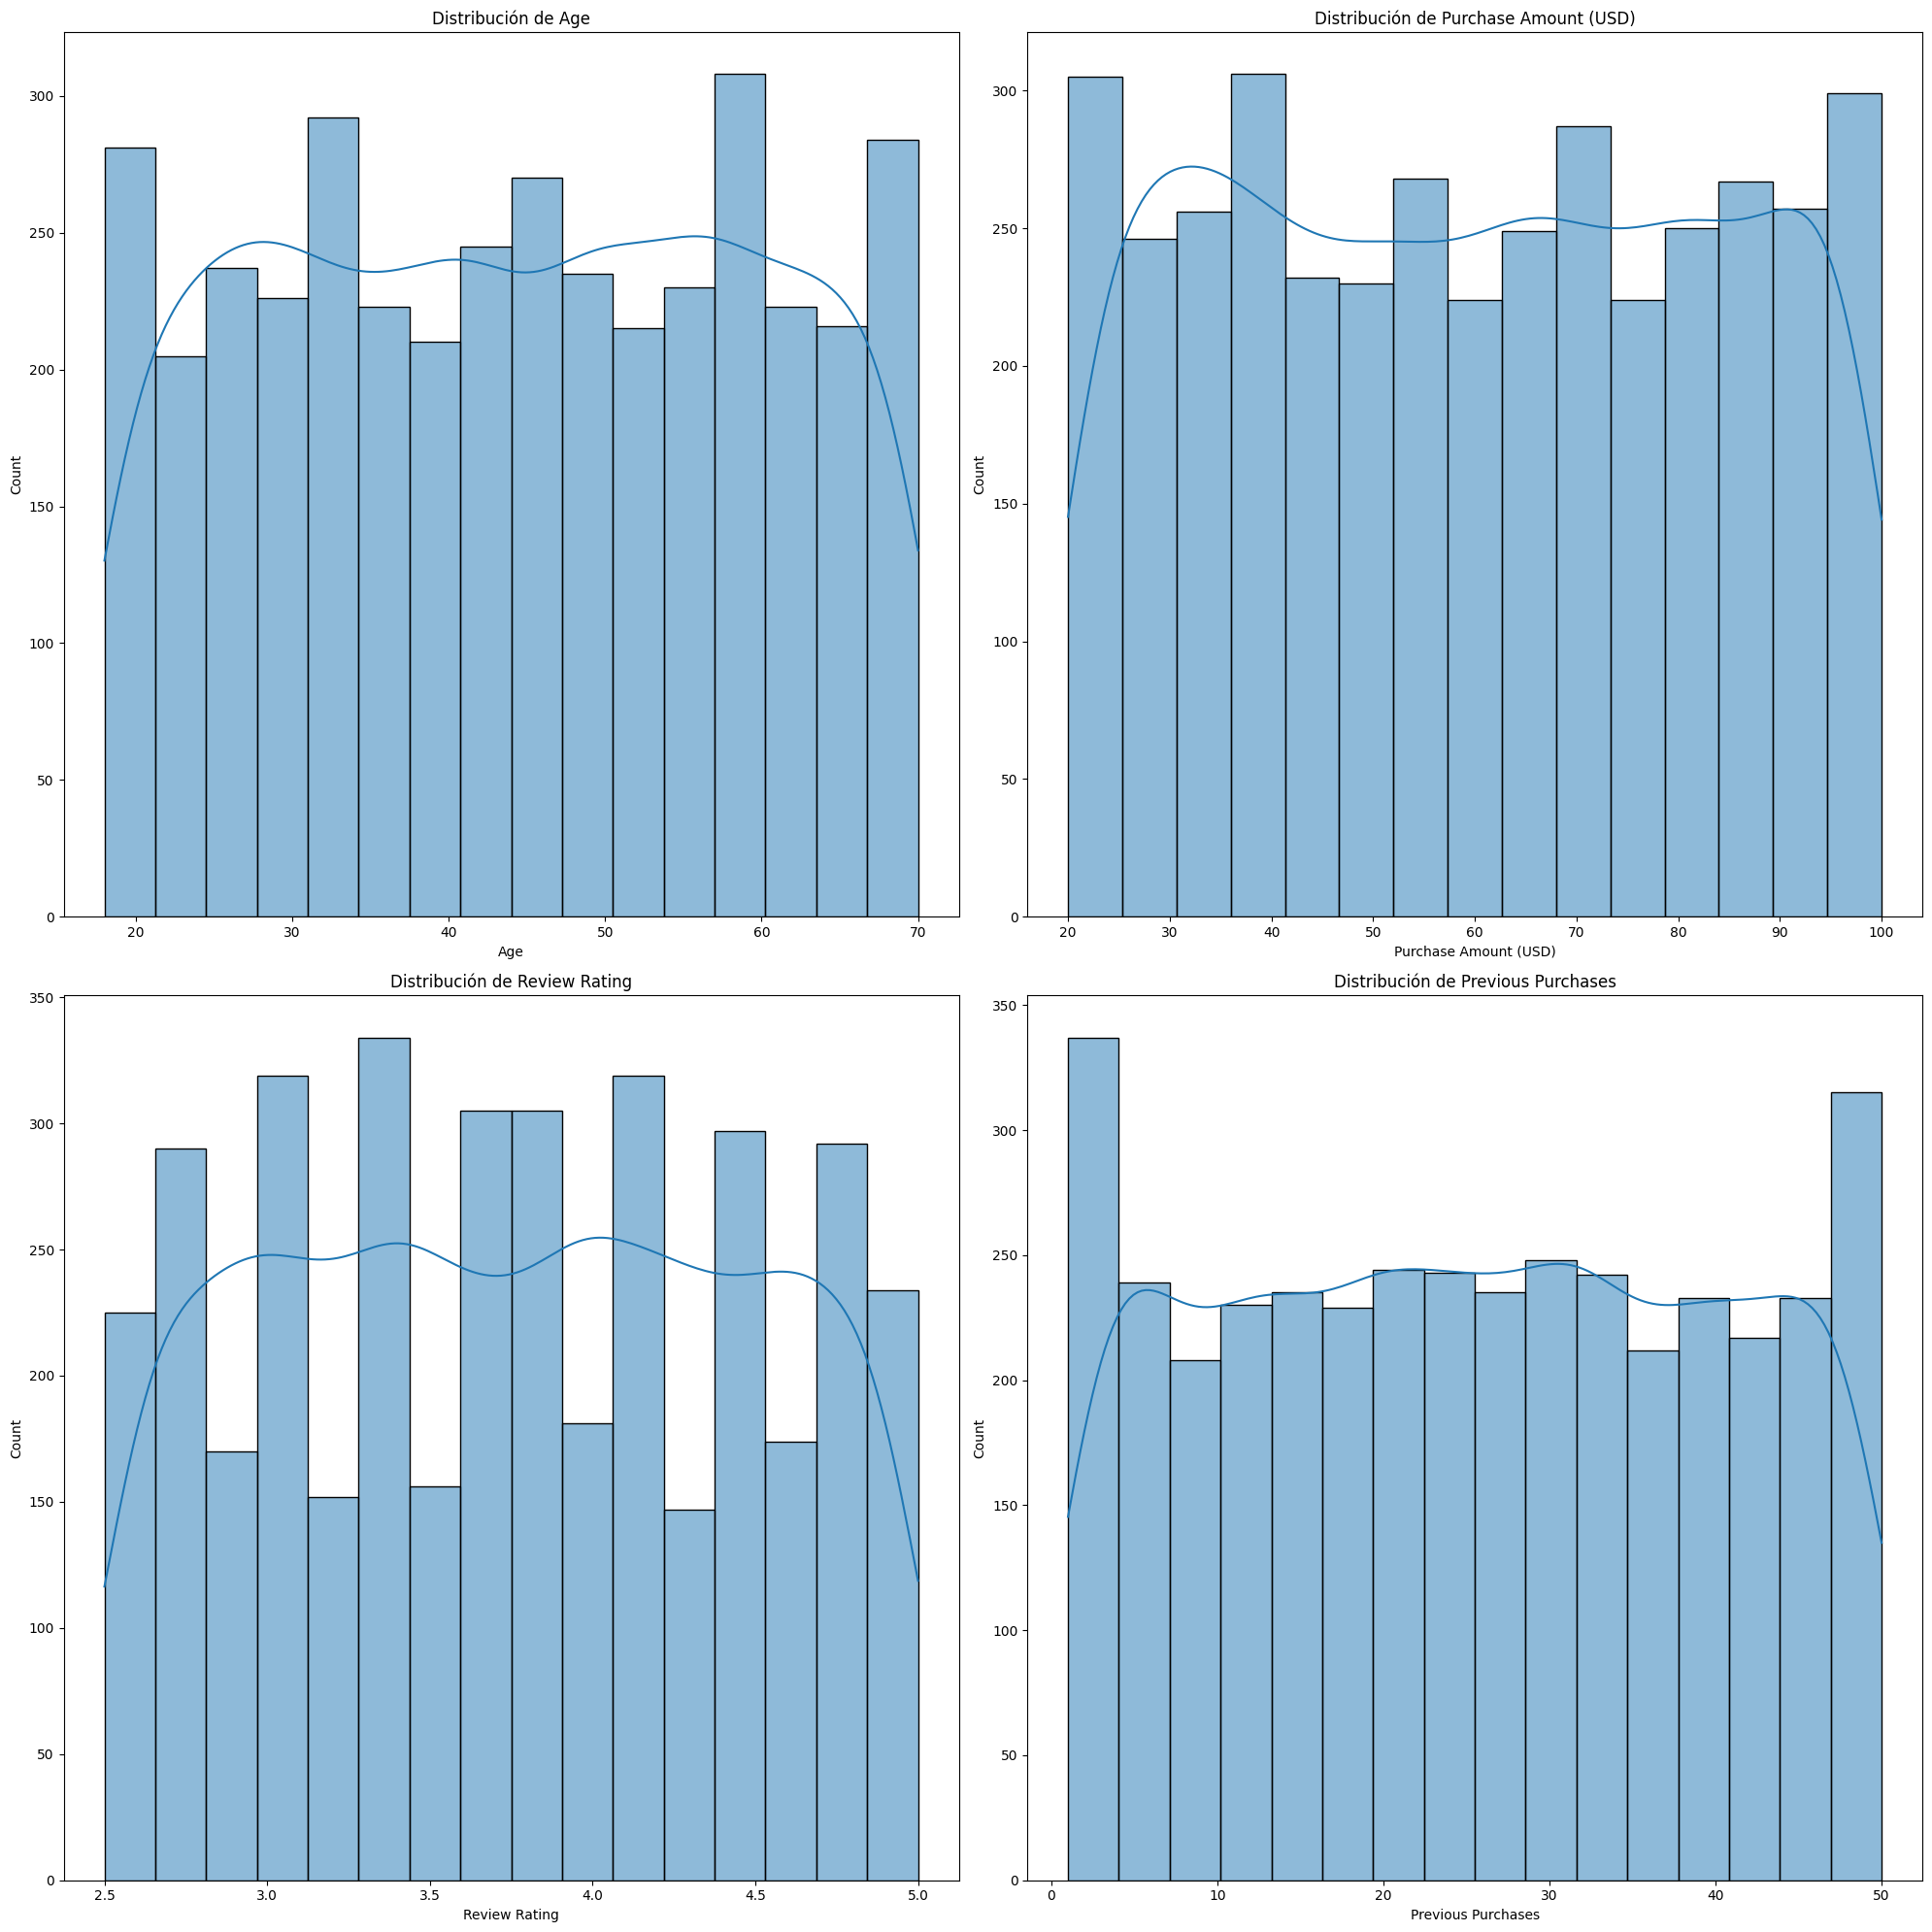

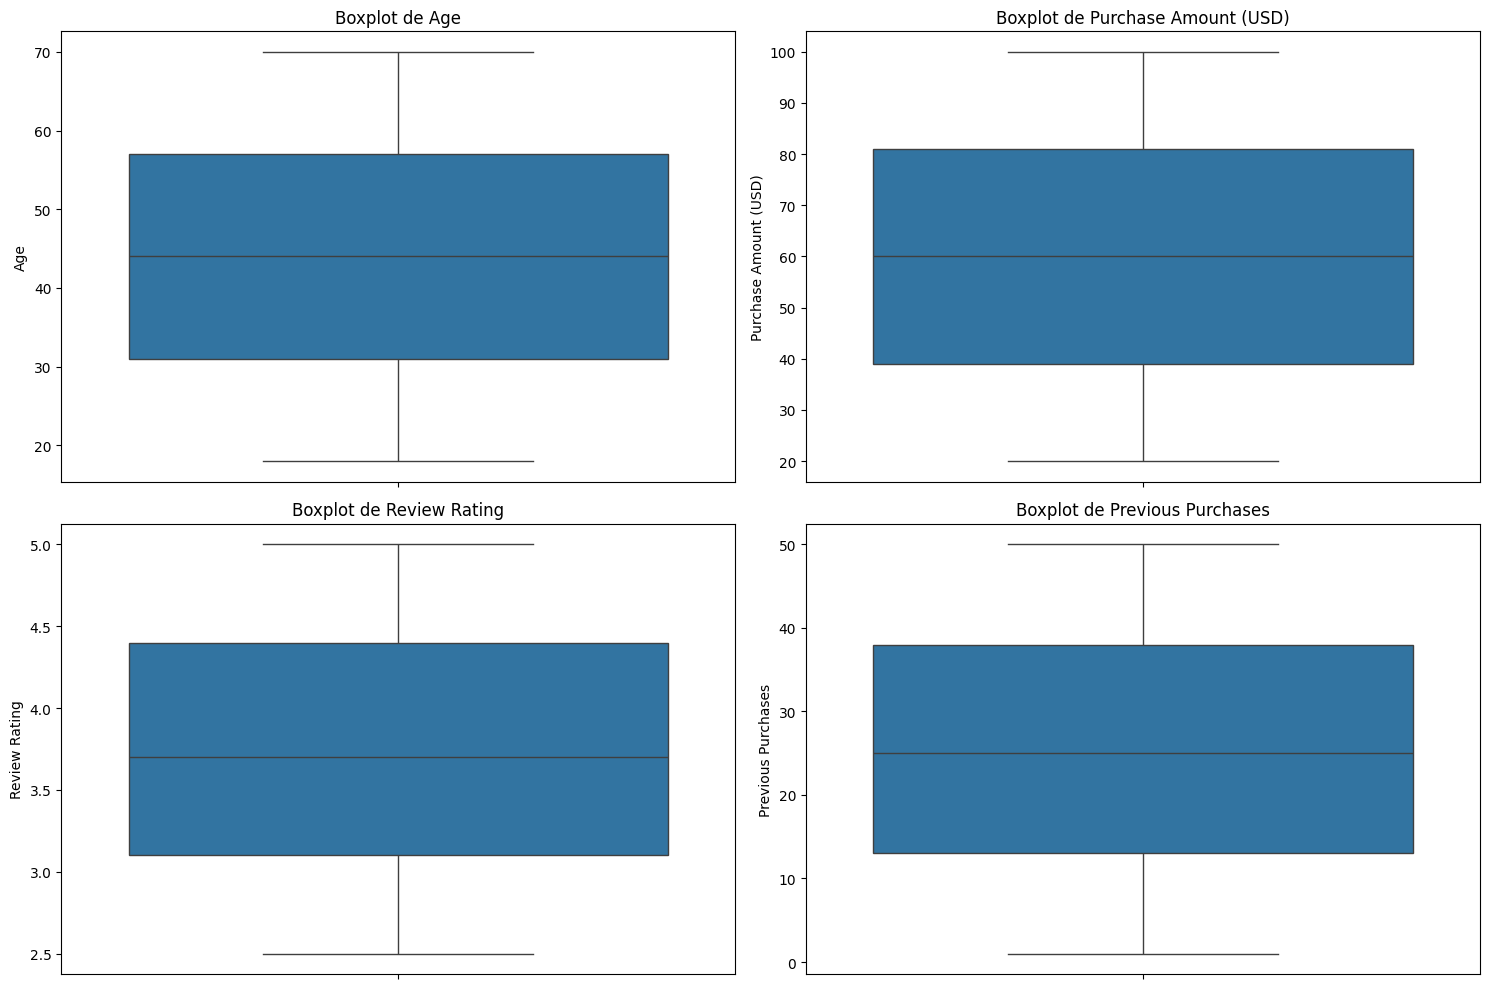

In [4]:
# Histograms para variables numéricas
plt.figure(figsize=(20, 20))
num_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

#boxplot para variables numericas
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

### Distribución de variables categóricas y binarias

/tmp/ipykernel_53487/2613098165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_53487/2613098165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_53487/2613098165.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_53487/2613098165.py:6: FutureWarning: 

Passing `palette` without assi

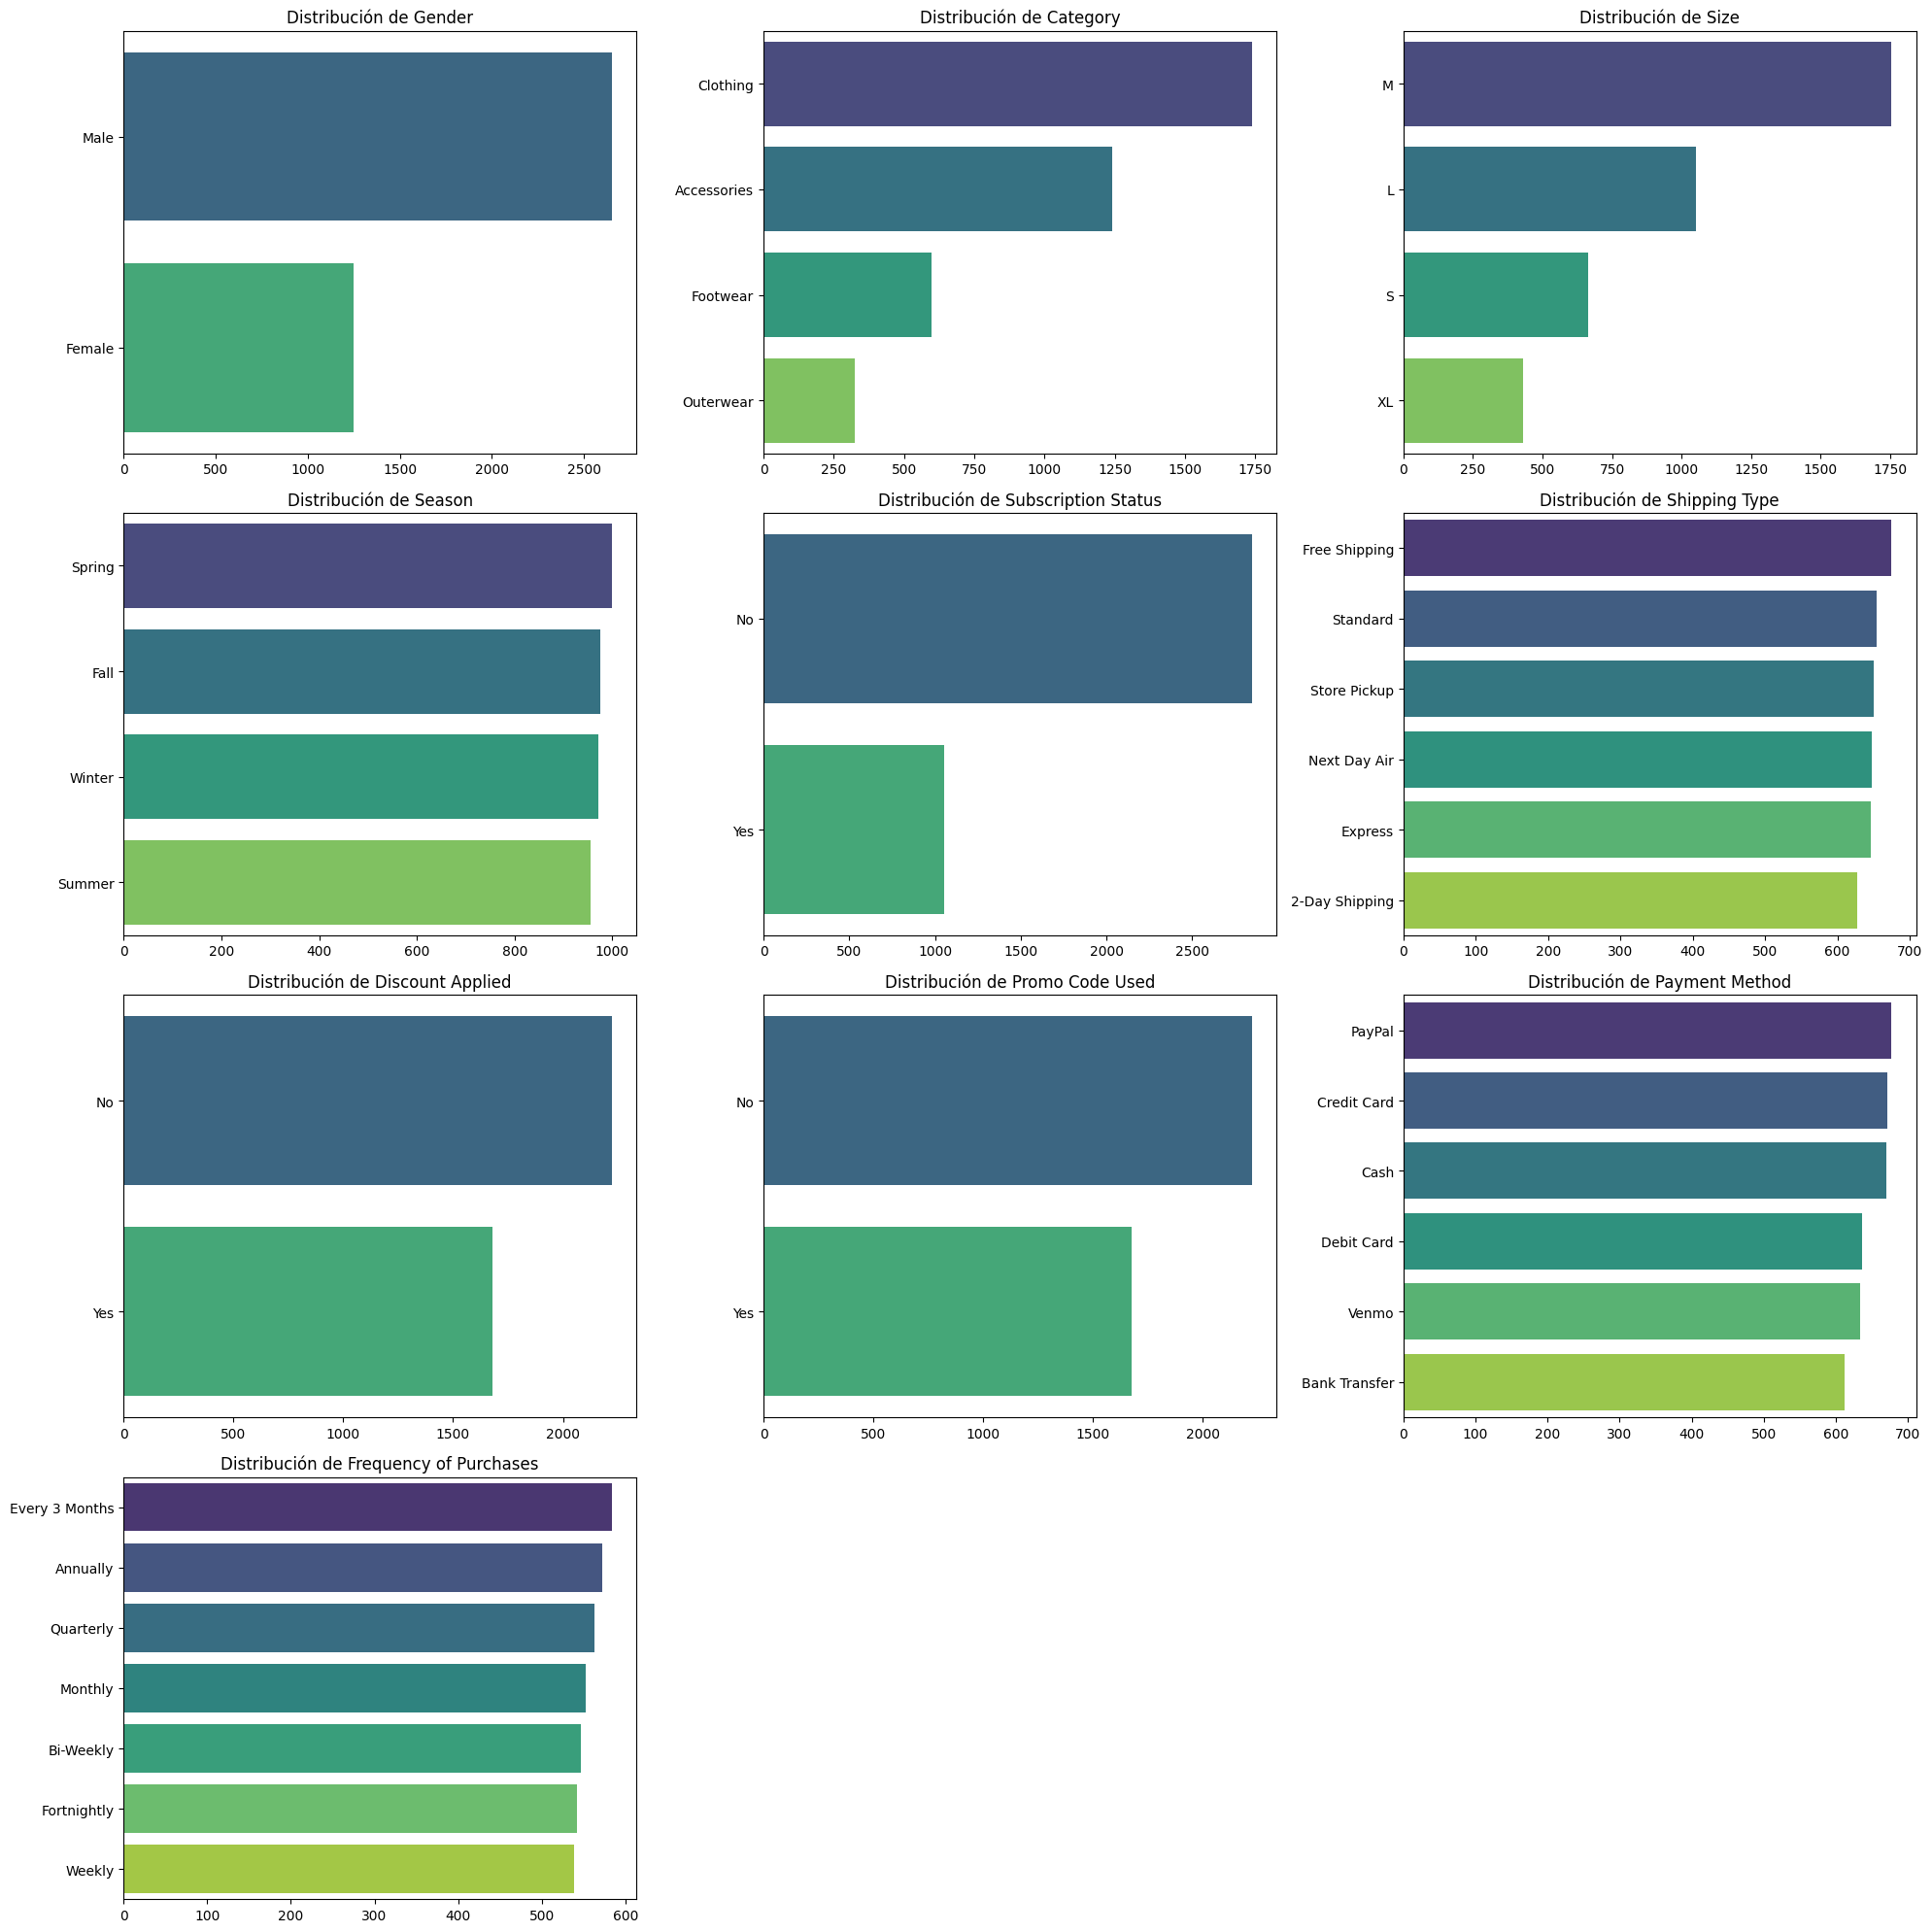

/tmp/ipykernel_53487/2613098165.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Item Purchased'], order=df['Item Purchased'].value_counts().head(10).index, palette='plasma')
/tmp/ipykernel_53487/2613098165.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Location'], order=df['Location'].value_counts().head(10).index, palette='magma')


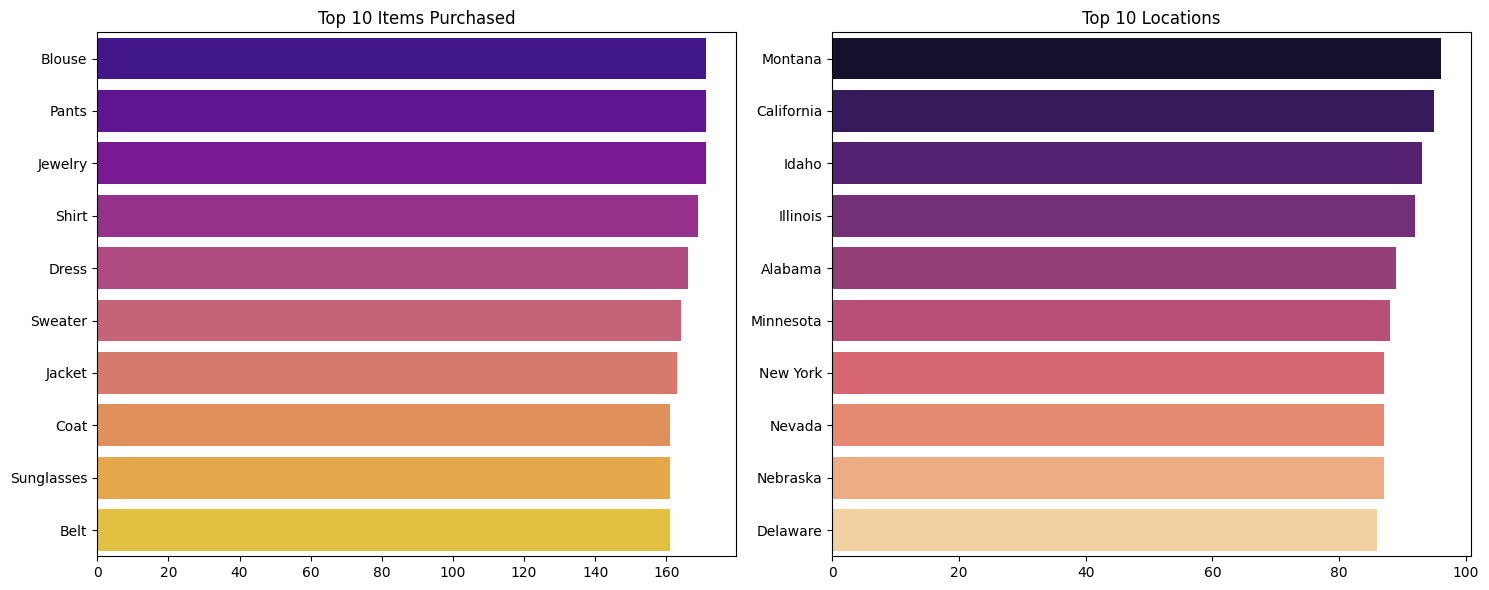

In [5]:
# Count plots para variables categóricas y binarias
plt.figure(figsize=(20, 20))
cat_cols = ['Gender', 'Category', 'Size', 'Season', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Payment Method', 'Frequency of Purchases']
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i + 1)
    sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()


# Para 'Item Purchased' y 'Location' que tienen muchas categorías, podemos visualizar las top N
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(y=df['Item Purchased'], order=df['Item Purchased'].value_counts().head(10).index, palette='plasma')
plt.title('Top 10 Items Purchased')
plt.xlabel('')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.countplot(y=df['Location'], order=df['Location'].value_counts().head(10).index, palette='magma')
plt.title('Top 10 Locations')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Matriz de Correlación de Variables Numéricas

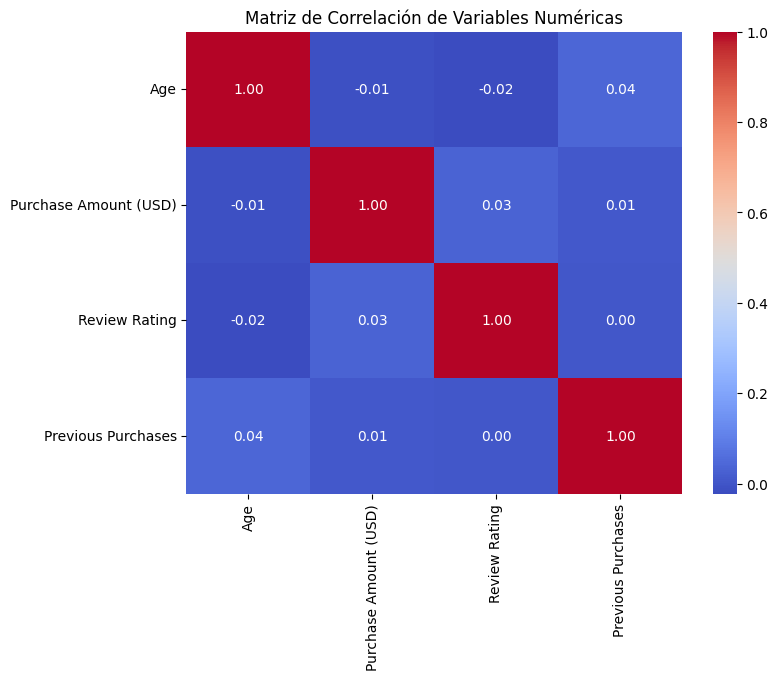

In [10]:
# Calcular la matriz de correlación para variables numéricas
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

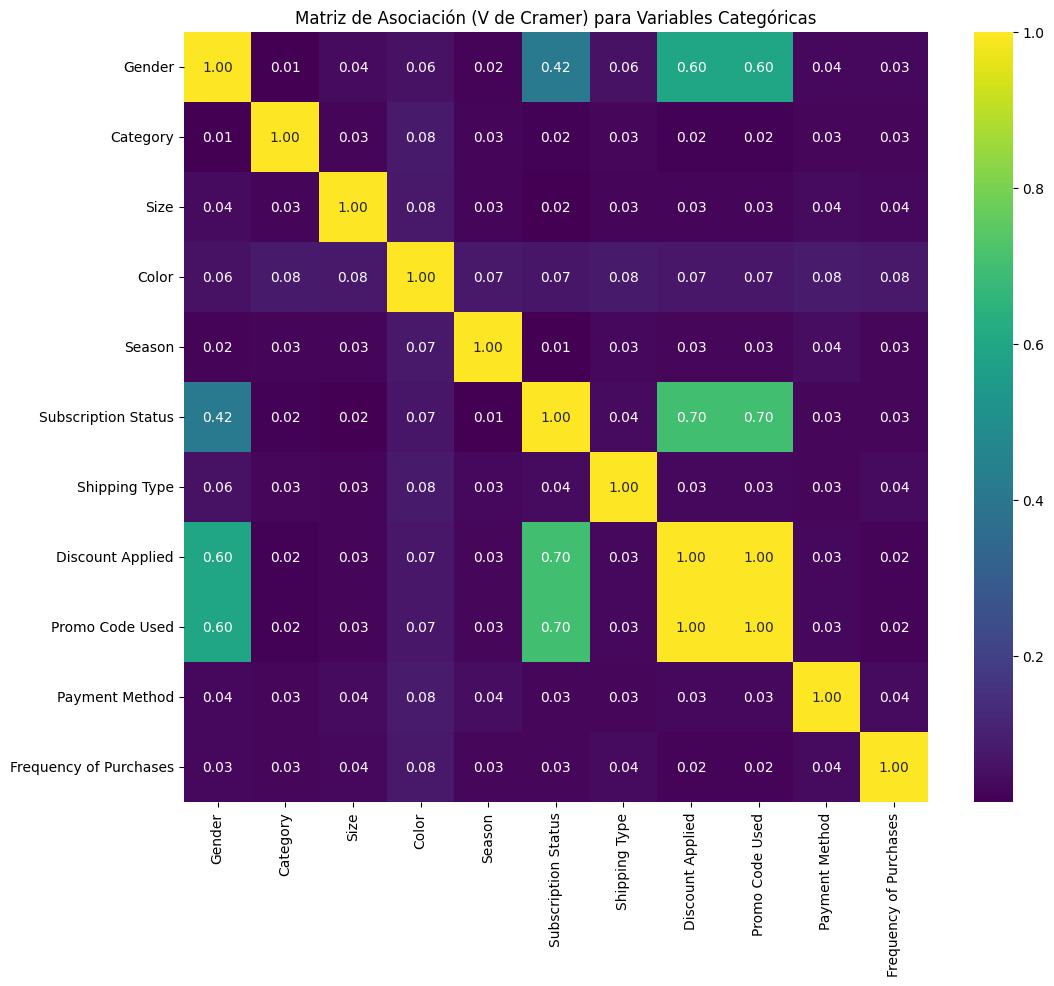

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    '''
    Calcula el coeficiente V de Cramer entre dos variables categóricas.
    Args:
        x (pd.Series): Primera variable categórica.
        y (pd.Series): Segunda variable categórica.
    Returns:
        float: El coeficiente V de Cramer.
    '''
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Handle cases where r or k is 1 to avoid division by zero or NaN
    if min(k, r) == 1:
        return 0.0  # No association can be measured if one variable has only one category
    v = np.sqrt(phi2 / min(k - 1, r - 1))
    return v

# Redefine df_processed, X, and categorical_features within this cell
# This ensures the variables are available for Cramer's V calculation
df_processed = df.drop(columns=['Customer ID', 'Location'])
target_variable = 'Item Purchased'
y = df_processed[target_variable]
X = df_processed.drop(columns=[target_variable])
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Obtener las variables categóricas del DataFrame X
categorical_data = X[categorical_features]

# Crear una matriz vacía para almacenar los valores de V de Cramer
cramers_v_matrix = pd.DataFrame(index=categorical_features, columns=categorical_features)

# Calcular V de Cramer para cada par de variables categóricas
for col1 in categorical_features:
    for col2 in categorical_features:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0 # Una variable consigo misma tiene asociación perfecta
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(categorical_data[col1], categorical_data[col2])

# Convertir la matriz a tipo float para el heatmap
cramers_v_matrix = cramers_v_matrix.astype(float)

# Visualizar la matriz de V de Cramer
plt.figure(figsize=(12, 10))
sns.heatmap(cramers_v_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title("Matriz de Asociación (V de Cramer) para Variables Categóricas")
plt.show()

### Interpretación

Explica qué descubriste en la exploración:
en la exploracion del dataset no se encuentran valores nulos, pero tampoco hay una correlacion relevante entre las columnas numericas, esto podra ser una problematica para realizar la regresion lineal y el modelo predictivo, una muy buena ventaja es que no se observan datos atipicos. En la correlacion de variables categoricas si se haya varias correlaciones positivas


##Preparación de datos

En esta sección deben:
- limpiar datos
- transformar variables si es necesario
- seleccionar variables
- definir X e y
- dividir en entrenamiento y prueba
- escalar datos si aplica


In [12]:
df_model = df.copy()

# Eliminar columnas no útiles
df_model.drop(columns=[
    'Customer ID',
    'Item Purchased',
    'Location',
    'Color'
], inplace=True)

# Convertir target binario
df_model['Discount Applied'] = df_model['Discount Applied'].map({'Yes':1, 'No':0})

# Label Encoding para binarias
binary_cols = ['Gender', 'Subscription Status', 'Promo Code Used']
le = LabelEncoder()

for col in binary_cols:
    df_model[col] = le.fit_transform(df_model[col])

# OneHot para pocas categorías
df_model = pd.get_dummies(df_model, columns=[
    'Category', 'Season', 'Size', 'Payment Method', 'Frequency of Purchases', 'Shipping Type' # Added 'Shipping Type'
], drop_first=True)

### Interpretación

Explica:
- qué decisiones tomaste para preparar los datos,
- por qué seleccionaste esas variables,
- y si fue necesario escalar o transformar datos.

Para la preparación de los datos se realizaron las siguientes decisiones:

**NO usamos:**

* Item Purchased (demasiadas categorías)
* Location (50 estados → ruido)
* Color (demasiadas categorías)

**Usamos:**

* Category (4 valores)
* Season (4 valores)
* Size (4 valores)
* Gender
* Subscription Status
* Payment Method
* Frequency of Purchases

**Encoding inteligente** (no abusar de OneHot)
* Variables con pocas categorías → OneHot
* Variables ordinales → Label Encoding

**Escalado**
* KNN → necesita escala
* Regresión y Naive Bayes → no obligatorio

## Kernels en SVM


Debido a que anteriormente no pudimos realizar el ejercicio de regresion linea porque los datos no tenian un comportamiento lineal, nos enfocaremos de nuevo en predecir el Purchase Amount (USD), es decir, la cantidad de dinero que un cliente gastará en una futura compra.

In [13]:
# Definir X y y para la tarea de clasificación (predicción de 'Discount Applied')
# Se excluye 'Purchase Amount (USD)' porque es el target de regresión original
# y 'Promo Code Used' para evitar fuga de datos (data leakage) como se identificó antes.
X_clf_svc = df_model.drop(columns=['Purchase Amount (USD)', 'Discount Applied', 'Promo Code Used'])
y_clf_svc = df_model['Discount Applied']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_clf_svc, X_test_clf_svc, y_train_clf_svc, y_test_clf_svc = train_test_split(X_clf_svc, y_clf_svc, test_size=0.2, random_state=42)

# Escalar las características - IMPRESCINDIBLE para SVM
scaler_clf_svc = StandardScaler()
X_train_scaled_clf_svc = scaler_clf_svc.fit_transform(X_train_clf_svc)
X_test_scaled_clf_svc = scaler_clf_svc.transform(X_test_clf_svc)

print("Datos preparados para SVC:")
print(f"X_train_scaled_clf_svc shape: {X_train_scaled_clf_svc.shape}")
print(f"y_train_clf_svc shape: {y_train_clf_svc.shape}")

Datos preparados para SVC:
X_train_scaled_clf_svc shape: (3120, 30)
y_train_clf_svc shape: (3120,)



--- SVC con Kernel Lineal ---
Accuracy (Linear Kernel): 0.8256410256410256
Classification Report (Linear Kernel):
               precision    recall  f1-score   support

           0       0.76      1.00      0.86       422
           1       1.00      0.62      0.77       358

    accuracy                           0.83       780
   macro avg       0.88      0.81      0.81       780
weighted avg       0.87      0.83      0.82       780



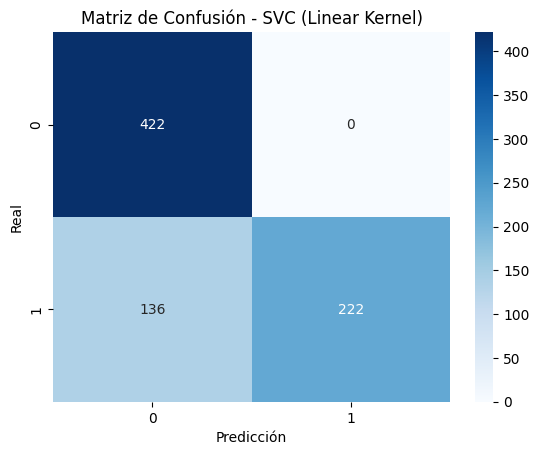

ROC-AUC (Linear Kernel): 0.9163


In [14]:
# --- 1. SVC con Kernel Lineal ---
print("\n--- SVC con Kernel Lineal ---")
svc_linear = SVC(kernel='linear', random_state=42, probability=True)
svc_linear.fit(X_train_scaled_clf_svc, y_train_clf_svc)
y_pred_svc_linear = svc_linear.predict(X_test_scaled_clf_svc)
y_prob_svc_linear = svc_linear.predict_proba(X_test_scaled_clf_svc)[:, 1]

# Evaluación
print("Accuracy (Linear Kernel):", accuracy_score(y_test_clf_svc, y_pred_svc_linear))
print("Classification Report (Linear Kernel):\n", classification_report(y_test_clf_svc, y_pred_svc_linear))

sns.heatmap(confusion_matrix(y_test_clf_svc, y_pred_svc_linear), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - SVC (Linear Kernel)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ROC-AUC
fpr_linear, tpr_linear, _ = roc_curve(y_test_clf_svc, y_prob_svc_linear)
roc_auc_linear = auc(fpr_linear, tpr_linear)
print(f"ROC-AUC (Linear Kernel): {roc_auc_linear:.4f}")


--- SVC con Kernel RBF ---
Accuracy (RBF Kernel): 0.8269230769230769
Classification Report (RBF Kernel):
               precision    recall  f1-score   support

           0       0.76      0.99      0.86       422
           1       0.98      0.64      0.77       358

    accuracy                           0.83       780
   macro avg       0.87      0.81      0.82       780
weighted avg       0.86      0.83      0.82       780



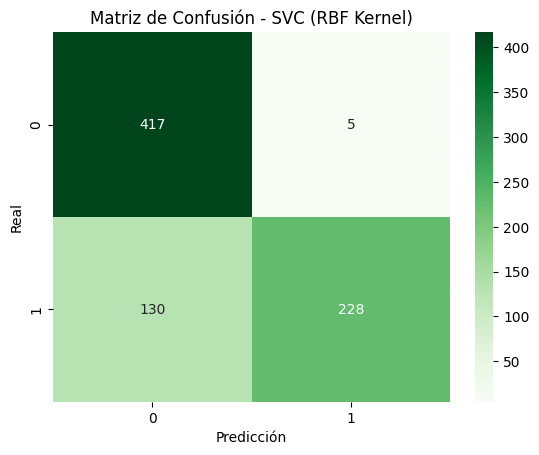

ROC-AUC (RBF Kernel): 0.9045


In [15]:
# --- 2. SVC con Kernel RBF ---
print("\n--- SVC con Kernel RBF ---")
# 'gamma=scale' usa 1 / (n_features * X.var()) como valor de gamma
svc_rbf = SVC(kernel='rbf', random_state=42, probability=True)
svc_rbf.fit(X_train_scaled_clf_svc, y_train_clf_svc)
y_pred_svc_rbf = svc_rbf.predict(X_test_scaled_clf_svc)
y_prob_svc_rbf = svc_rbf.predict_proba(X_test_scaled_clf_svc)[:, 1]

# Evaluación
print("Accuracy (RBF Kernel):", accuracy_score(y_test_clf_svc, y_pred_svc_rbf))
print("Classification Report (RBF Kernel):\n", classification_report(y_test_clf_svc, y_pred_svc_rbf))

sns.heatmap(confusion_matrix(y_test_clf_svc, y_pred_svc_rbf), annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - SVC (RBF Kernel)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ROC-AUC
fpr_rbf, tpr_rbf, _ = roc_curve(y_test_clf_svc, y_prob_svc_rbf)
roc_auc_rbf = auc(fpr_rbf, tpr_rbf)
print(f"ROC-AUC (RBF Kernel): {roc_auc_rbf:.4f}")


--- SVC con Kernel Polinomial ---
Accuracy (Polynomial Kernel): 0.8115384615384615
Classification Report (Polynomial Kernel):
               precision    recall  f1-score   support

           0       0.77      0.94      0.84       422
           1       0.90      0.66      0.76       358

    accuracy                           0.81       780
   macro avg       0.83      0.80      0.80       780
weighted avg       0.83      0.81      0.81       780



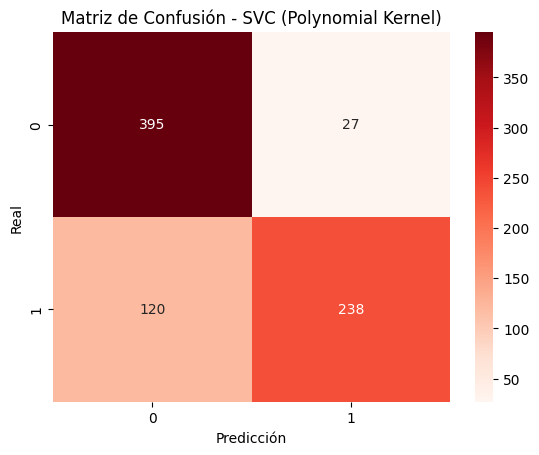

ROC-AUC (Polynomial Kernel): 0.9030


In [16]:
# --- 3. SVC con Kernel Polinomial ---
print("\n--- SVC con Kernel Polinomial ---")
# Se puede ajustar 'degree' para el grado del polinomio
svc_poly = SVC(kernel='poly', degree=3, random_state=42, probability=True)
svc_poly.fit(X_train_scaled_clf_svc, y_train_clf_svc)
y_pred_svc_poly = svc_poly.predict(X_test_scaled_clf_svc)
y_prob_svc_poly = svc_poly.predict_proba(X_test_scaled_clf_svc)[:, 1]

# Evaluación
print("Accuracy (Polynomial Kernel):", accuracy_score(y_test_clf_svc, y_pred_svc_poly))
print("Classification Report (Polynomial Kernel):\n", classification_report(y_test_clf_svc, y_pred_svc_poly))

sns.heatmap(confusion_matrix(y_test_clf_svc, y_pred_svc_poly), annot=True, fmt='d', cmap='Reds')
plt.title("Matriz de Confusión - SVC (Polynomial Kernel)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# ROC-AUC
fpr_poly, tpr_poly, _ = roc_curve(y_test_clf_svc, y_prob_svc_poly)
roc_auc_poly = auc(fpr_poly, tpr_poly)
print(f"ROC-AUC (Polynomial Kernel): {roc_auc_poly:.4f}")

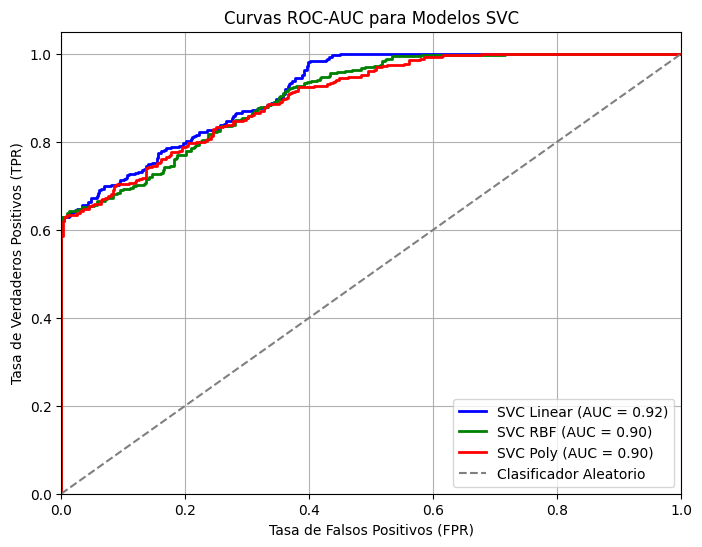

In [17]:
# --- Curvas ROC-AUC para todos los modelos SVC ---
plt.figure(figsize=(8, 6))
plt.plot(fpr_linear, tpr_linear, color='blue', lw=2, label=f'SVC Linear (AUC = {roc_auc_linear:.2f})')
plt.plot(fpr_rbf, tpr_rbf, color='green', lw=2, label=f'SVC RBF (AUC = {roc_auc_rbf:.2f})')
plt.plot(fpr_poly, tpr_poly, color='red', lw=2, label=f'SVC Poly (AUC = {roc_auc_poly:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador Aleatorio')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC-AUC para Modelos SVC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Interpretación y Evaluación de los Modelos SVC

Aquí analizaremos los resultados de los modelos SVC con diferentes kernels, predecir si una compra tendrá descuento (`Discount Applied`).

**Evaluación General de SVC:**

Los modelos SVC, al igual que la Regresión Logística, muestran un buen desempeño general, con Accuracies superiores al 80%. Son particularmente efectivos en la **precisión** para la clase positiva (1: 'Descuento Aplicado'), lo que significa que cuando predicen un descuento, es muy probable que acierten. Sin embargo, su **recall** para esta clase es más bajo, indicando que no detectan todos los casos reales donde se aplicó un descuento.

**SVC con Kernel Lineal:**
*   **Accuracy:** 0.8256
*   **Precision (Clase 1):** 1.00
*   **Recall (Clase 1):** 0.62
*   **F1-score (Clase 1):** 0.77
*   **ROC-AUC:** 0.9163

**Análisis:** Este kernel intenta encontrar un límite de decisión lineal entre las clases. Su `precision` de 1.00 para la clase 1 es excepcional, indicando que cada vez que predice un descuento, lo hace correctamente. Sin embargo, su `recall` de 0.62 revela que solo identifica el 62% de los descuentos reales, lo que significa que hay una cantidad considerable de falsos negativos.

**SVC con Kernel RBF (Radial Basis Function):**
*   **Accuracy:** 0.8269
*   **Precision (Clase 1):** 0.98
*   **Recall (Clase 1):** 0.64
*   **F1-score (Clase 1):** 0.77
*   **ROC-AUC:** 0.9045

**Análisis:** El kernel RBF permite al SVC encontrar límites de decisión no lineales. Presenta una `Accuracy` ligeramente superior al lineal. Su `precision` para la Clase 1 sigue siendo muy alta (0.98), con muy pocos falsos positivos. El `recall` para la Clase 1 mejora ligeramente a 0.64, lo que indica que detecta un porcentaje un poco mayor de descuentos reales que el kernel lineal, pero aún tiene margen de mejora en la detección de todos los casos positivos.

**SVC con Kernel Polinomial (grado 3):**
*   **Accuracy:** 0.8115
*   **Precision (Clase 1):** 0.90
*   **Recall (Clase 1):** 0.66
*   **F1-score (Clase 1):** 0.76
*   **ROC-AUC:** 0.9030

**Análisis:** El kernel polinomial de grado 3 introduce una mayor complejidad. En este caso, su `Accuracy` y `Precision` para la Clase 1 son ligeramente inferiores a los kernels Lineal y RBF. Sin embargo, su `Recall` para la Clase 1 es el más alto de los tres (0.66), lo que significa que logra identificar una proporción ligeramente mayor de los descuentos reales, a expensas de una precisión un poco menor. Esto podría ser un punto a favor si el objetivo es maximizar la detección de descuentos, incluso si hay algunos falsos positivos más.

**Overfitting vs Underfitting:**

Al comparar los rendimientos, ninguno de los modelos muestra signos claros de `overfitting` severo, ya que las métricas en el conjunto de prueba son consistentes con un buen aprendizaje. El modelo RBF y Polinomial, al ser más complejos, tienen un rendimiento general (Accuracy) comparable o ligeramente inferior al Lineal en este dataset. Esto podría indicar que las relaciones no son extremadamente no lineales o que los hiperparámetros actuales para RBF y Polinomial (especialmente `C` y `gamma`/`degree`) no están optimizados. Para una mejora significativa con kernels no lineales, a menudo se requiere una sintonización más cuidadosa de hiperparámetros.

La comparación de las curvas ROC-AUC también nos confirma que los tres kernels tienen una buena capacidad para distinguir entre las clases, con el kernel lineal mostrando un AUC ligeramente superior.


--- Evaluación de Overfitting para SVC ---

Linear SVC:
  Train Accuracy: 0.8436
  Test Accuracy: 0.8256

RBF SVC:
  Train Accuracy: 0.8705
  Test Accuracy: 0.8269

Polynomial SVC:
  Train Accuracy: 0.9212
  Test Accuracy: 0.8115


,Model,Train Accuracy,Test Accuracy
0,Linear SVC,0.843590,0.825641
1,RBF SVC,0.870513,0.826923
2,Polynomial SVC,0.921154,0.811538


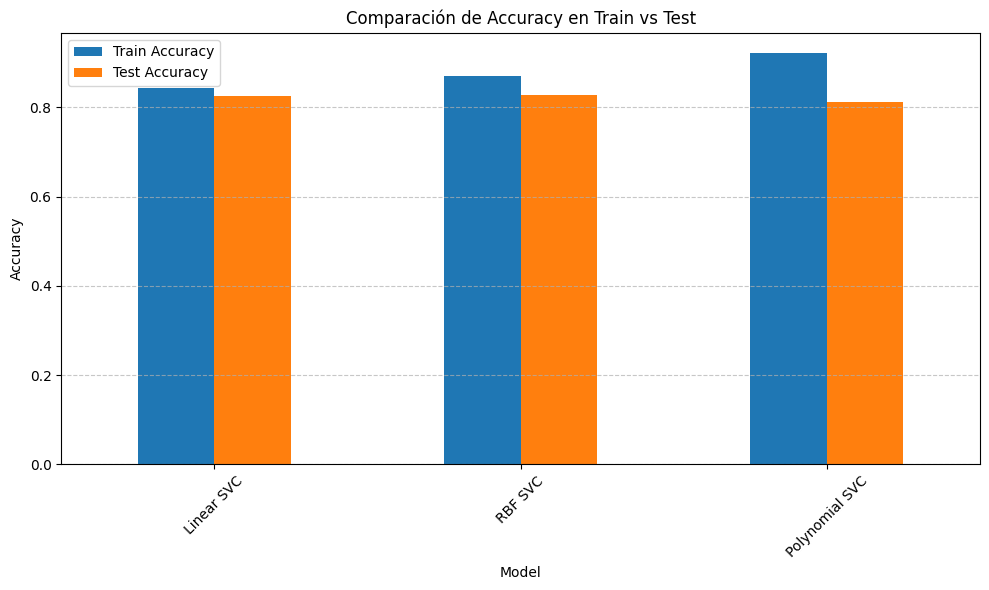

In [38]:

print("\n--- Evaluación de Overfitting para SVC ---")

models = {
    'Linear SVC': SVC(kernel='linear', random_state=42),
    'RBF SVC': SVC(kernel='rbf', random_state=42),
    'Polynomial SVC': SVC(kernel='poly', degree=3, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled_clf_svc, y_train_clf_svc)

    y_train_pred = model.predict(X_train_scaled_clf_svc)
    train_accuracy = accuracy_score(y_train_clf_svc, y_train_pred)

    y_test_pred = model.predict(X_test_scaled_clf_svc)
    test_accuracy = accuracy_score(y_test_clf_svc, y_test_pred)

    results.append({'Model': name, 'Train Accuracy': train_accuracy, 'Test Accuracy': test_accuracy})
    print(f"\n{name}:")
    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Test Accuracy: {test_accuracy:.4f}")

df_overfitting_results = pd.DataFrame(results)
display(df_overfitting_results)

# Comparación visual
df_overfitting_results.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de Accuracy en Train vs Test')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretación de Overfitting

Analizando los resultados de cada modelo SVC:

*   **SVC Lineal:**
    *   **Train Accuracy:** 0.8436
    *   **Test Accuracy:** 0.8256
    *   **Análisis:** La diferencia entre la precisión de entrenamiento y prueba es mínima (aproximadamente 0.018). Esto sugiere que el modelo lineal no está sobreajustando y está capturando las relaciones generales de los datos de manera efectiva. Generaliza bien a datos no vistos.

*   **SVC RBF:**
    *   **Train Accuracy:** 0.8705
    *   **Test Accuracy:** 0.8269
    *   **Análisis:** Se observa una diferencia mayor (aproximadamente 0.0436) entre la precisión de entrenamiento y prueba en comparación con el modelo lineal. Esto indica un **sobreajuste moderado**. El modelo RBF tiene más capacidad para aprender relaciones complejas, y aquí parece haber aprendido algunos patrones específicos del conjunto de entrenamiento que no se generalizan completamente al conjunto de prueba. A pesar de esto, su precisión en el test sigue siendo muy buena.

*   **SVC Polinomial (grado 3):**
    *   **Train Accuracy:** 0.9212
    *   **Test Accuracy:** 0.8115
    *   **Análisis:** Este modelo muestra la mayor diferencia entre la precisión de entrenamiento y prueba (aproximadamente 0.1097). Su alta precisión de entrenamiento, combinada con una precisión de prueba notablemente inferior (e incluso ligeramente menor que el SVC Lineal y RBF), es una señal clara de **sobreajuste significativo**. El kernel polinomial de grado 3 es el más complejo de los tres y parece haber memorizado el ruido y los detalles específicos de los datos de entrenamiento, perdiendo capacidad de generalización.

**Conclusión:**

La **Regresión Logística** y el **SVC Lineal** muestran el mejor equilibrio entre rendimiento en entrenamiento y test, indicando una buena capacidad de generalización con un sobreajuste mínimo. El **SVC RBF** presenta un sobreajuste moderado, que aún puede ser aceptable dependiendo del contexto. Sin embargo, el **SVC Polinomial** con grado 3 muestra un sobreajuste considerable, lo que lo hace menos confiable para predecir en datos nuevos y no vistos. Para el SVC RBF y Polinomial, una optimización de hiperparámetros (como `C` y `gamma`/`degree`) podría ayudar a mitigar el sobreajuste y mejorar la capacidad de generalización.

### Visualización de la Separación de Clases y Fronteras de Decisión

Para entender mejor el desempeño de los modelos de clasificación, especialmente cuando la separación entre clases no es perfecta, es útil visualizar los datos y las fronteras de decisión que los modelos han aprendido. Esto puede ayudar a identificar si las características utilizadas permiten una distinción clara entre las clases o si existe un solapamiento significativo.


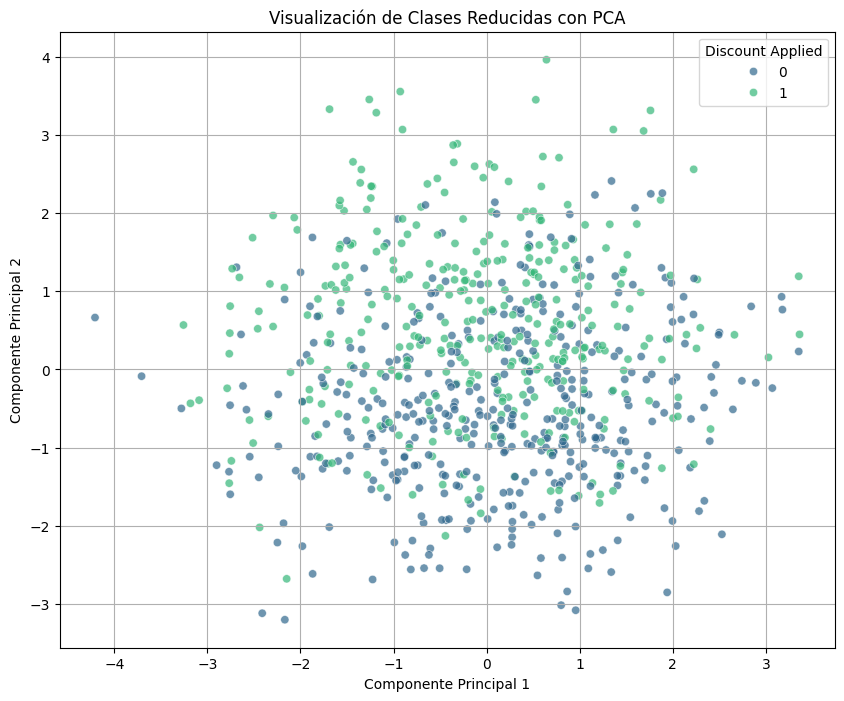

In [22]:
# Vamos a visualizar la separación de clases usando PCA para reducir la dimensionalidad a 2 componentes.
# Usaremos el conjunto de prueba escalado (X_test_scaled_clf_svc) y las etiquetas reales (y_test_clf_svc).

pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled_clf_svc)

# Crear un DataFrame para la visualización
df_viz = pd.DataFrame(data = X_test_pca, columns = ['principal component 1', 'principal component 2'])
df_viz['Discount Applied'] = y_test_clf_svc.values

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal component 1',
    y='principal component 2',
    hue='Discount Applied',
    data=df_viz,
    palette='viridis',
    alpha=0.7
)
plt.title('Visualización de Clases Reducidas con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()


### Interpretación de la Visualización

En este gráfico (generado a partir de la reducción de dimensionalidad con PCA), se puede observar la distribución de los puntos de datos para las dos clases ('0: Sin Descuento' y '1: Con Descuento').

* **Solapamiento (Overlap)**: Los puntos que representan una clase y otra se mezclan considerablemente en el gráfico, indicando que no hay una frontera clara o una separación lineal entre ellas.

* **Implicaciones para el Modelo:** Un solapamiento significativo explica por qué los modelos de clasificación podrían tener dificultades para lograr una alta precisión y recall simultáneamente para ambas clases. El modelo tendrá que tomar decisiones en áreas donde ambas clases están presentes, lo que llevará a errores (falsos positivos y falsos negativos).

Esta visualización apoya las conclusiones obtenidas de las métricas de evaluación, donde se observa que, si bien la precisión en una clase era alta, el recall en la otra clase podía ser más bajo debido a la dificultad inherente de los datos para ser perfectamente separados.

### Visualización Gráfica de Fronteras de Decisión de SVC con Kernels (Reducción PCA)

Para entender cómo cada kernel de SVC intenta separar las clases, podemos visualizar sus fronteras de decisión. Dado que los datos originales son multidimensionales, utilizaremos la Reducción de Componentes Principales (PCA) para proyectar los datos en 2 dimensiones y así poder graficar las fronteras de decisión de los modelos SVC entrenados con estos datos reducidos.

In [23]:
# Realizamos PCA en el conjunto de entrenamiento escalado
pca_decision_boundary = PCA(n_components=2)
X_train_pca_db = pca_decision_boundary.fit_transform(X_train_scaled_clf_svc)
X_test_pca_db = pca_decision_boundary.transform(X_test_scaled_clf_svc)

print("Datos de entrenamiento reducidos con PCA para visualización de fronteras de decisión:")
print(f"X_train_pca_db shape: {X_train_pca_db.shape}")
print(f"X_test_pca_db shape: {X_test_pca_db.shape}")

Datos de entrenamiento reducidos con PCA para visualización de fronteras de decisión:
X_train_pca_db shape: (3120, 2)
X_test_pca_db shape: (780, 2)


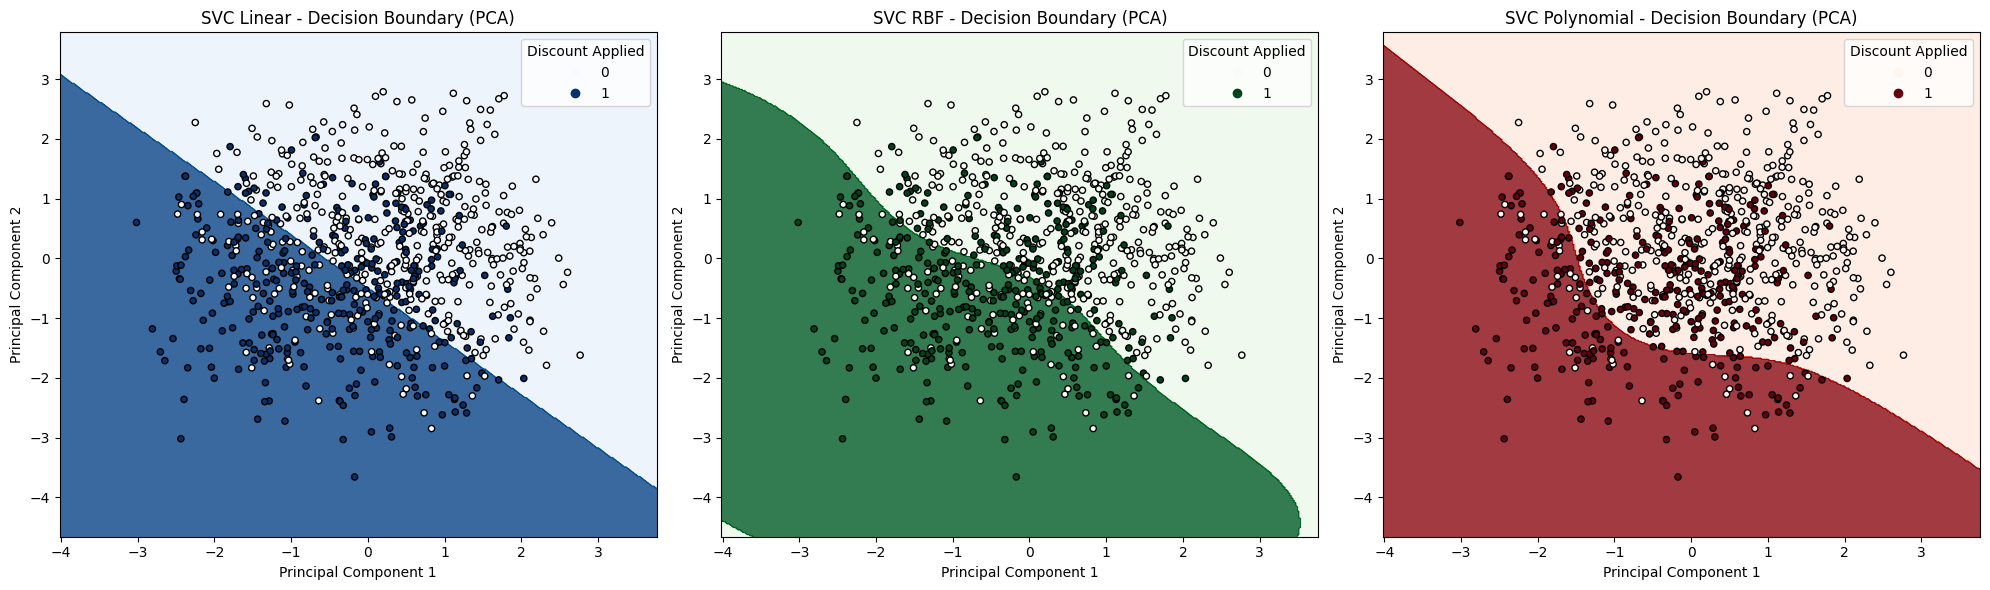

In [24]:
def plot_decision_boundaries(X, y, model, title, ax, cmap='viridis'):
    # Crear una malla para graficar las fronteras de decisión
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predecir en la malla y remodelar las predicciones
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Graficar las fronteras de decisión
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=cmap)

    # Graficar los puntos de datos reales
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolors='k', s=20)
    ax.set_title(title)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(*scatter.legend_elements(), title="Discount Applied")

# Re-entrenar modelos SVC con los datos PCA-reducidos para visualización
svc_linear_db = SVC(kernel='linear', random_state=42)
svc_linear_db.fit(X_train_pca_db, y_train_clf_svc)

svc_rbf_db = SVC(kernel='rbf', random_state=42)
svc_rbf_db.fit(X_train_pca_db, y_train_clf_svc)

svc_poly_db = SVC(kernel='poly', degree=3, random_state=42)
svc_poly_db.fit(X_train_pca_db, y_train_clf_svc)

# Graficar las fronteras de decisión
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_decision_boundaries(X_test_pca_db, y_test_clf_svc, svc_linear_db, 'SVC Linear - Decision Boundary (PCA)', axes[0], cmap='Blues')
plot_decision_boundaries(X_test_pca_db, y_test_clf_svc, svc_rbf_db, 'SVC RBF - Decision Boundary (PCA)', axes[1], cmap='Greens')
plot_decision_boundaries(X_test_pca_db, y_test_clf_svc, svc_poly_db, 'SVC Polynomial - Decision Boundary (PCA)', axes[2], cmap='Reds')

plt.tight_layout()
plt.show()

## Clustering K-Means

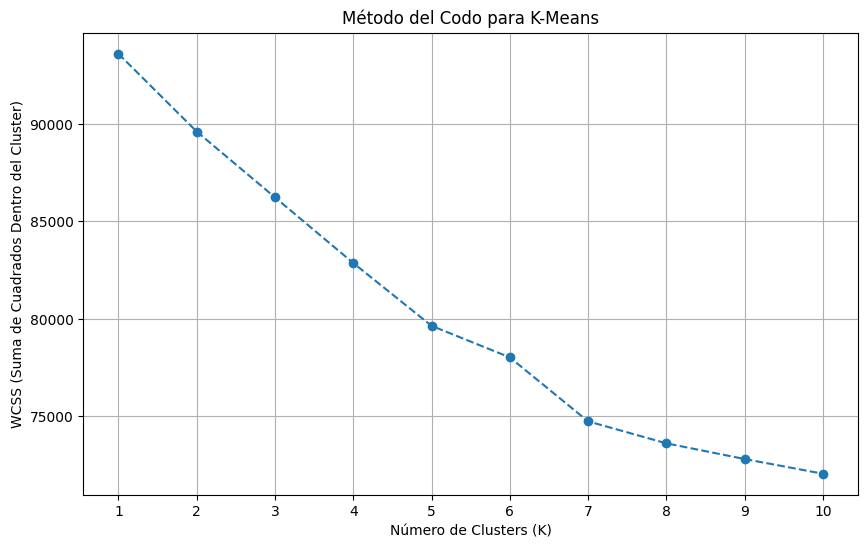

Silhouette Score para K=2: 0.0408
Silhouette Score para K=3: 0.0563
Silhouette Score para K=4: 0.0745
Silhouette Score para K=5: 0.0901
Silhouette Score para K=6: 0.0816
Silhouette Score para K=7: 0.0773
Silhouette Score para K=8: 0.0835
Silhouette Score para K=9: 0.0758
Silhouette Score para K=10: 0.0657


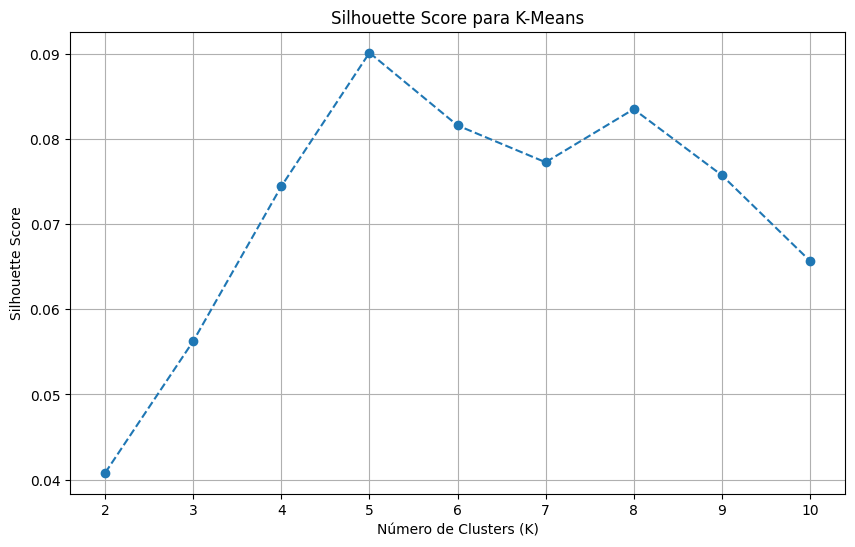

In [28]:
# Para K-Means, usaremos las mismas características que para SVC, pero sin la variable objetivo
# X_clf_svc ya está escalado y listo para usar en algoritmos basados en distancia.
X_clustering = X_train_scaled_clf_svc # Usaremos el conjunto de entrenamiento escalado para el clustering

# --- Método del Codo para encontrar el número óptimo de clusters ---
#Se busca el punto donde la disminución de la inercia cambia drásticamente,
#"codo" o "ala de pollo". Este punto indica el equilibrio entre la precisión y la complejidad.
wcss = [] # Suma de cuadrados dentro del cluster
for i in range(1, 11): # Probaremos de 1 a 10 clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_clustering)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Suma de Cuadrados Dentro del Cluster)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

# --- Calcular Silhouette Score para diferentes números de clusters ---
#Calcula la distancia media entre un punto y todos los demás puntos del mismo clúster a
# y la distancia media con el siguiente clúster más cercano (b).
silhouette_scores = []
for i in range(2, 11): # Silhouette score requiere al menos 2 clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_clustering)
    score = silhouette_score(X_clustering, cluster_labels)
    silhouette_scores.append(score)
    print(f"Silhouette Score para K={i}: {score:.4f}")

# Graficar el Silhouette Score
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### Interpretación del K-Means: Selección del Número Óptimo de Clusters

En esta sección, hemos utilizado dos métricas principales para evaluar el número óptimo de clusters para K-Means:

1.  **Método del Codo (Elbow Method):**
    *   **Análisis:** El gráfico del método del codo muestra la suma de cuadrados dentro del cluster (WCSS) para diferentes valores de K. Buscamos un "codo" o "punto de inflexión" donde la disminución del WCSS comienza a ser menos pronunciada. Este punto sugiere un buen equilibrio entre la compacidad de los clusters y la complejidad del modelo.
    *   **Conclusión:** Basado en el gráfico, un "codo" razonable se observa alrededor de **K=5**, donde la disminución en el WCSS comienza a ralentizarse de manera más notoria. Aunque no es un codo extremadamente pronunciado, sugiere que añadir más clusters después de 5 ofrece rendimientos decrecientes en la reducción de la varianza dentro de los clusters.

2.  **Silhouette Score:**
    *   **Análisis:** El Silhouette Score mide qué tan similar es un objeto a su propio cluster (cohesión) en comparación con otros clusters (separación). Los valores van de -1 a 1, donde un valor alto indica que el objeto está bien emparejado con su propio cluster y mal emparejado con clusters vecinos. Un valor cercano a 0 indica solapamiento entre clusters, y valores negativos sugieren que los objetos podrían haberse asignado al cluster incorrecto.
    *   **Conclusión:** Observando los Silhouette Scores para diferentes valores de K, el valor más alto es de **0.0901 para K=5**. Esto indica que, en promedio, los objetos dentro de sus clusters están mejor definidos y separados de otros clusters en comparación con otros valores de K probados.

**Selección Final del Número de Clusters:**

Considerando ambos métodos, se seleccionará un valor de **K=5** para el análisis posterior. Este valor representa el mejor compromiso entre la reducción de la varianza intra-cluster (Método del Codo) y la coherencia y separación de los clusters (Silhouette Score).

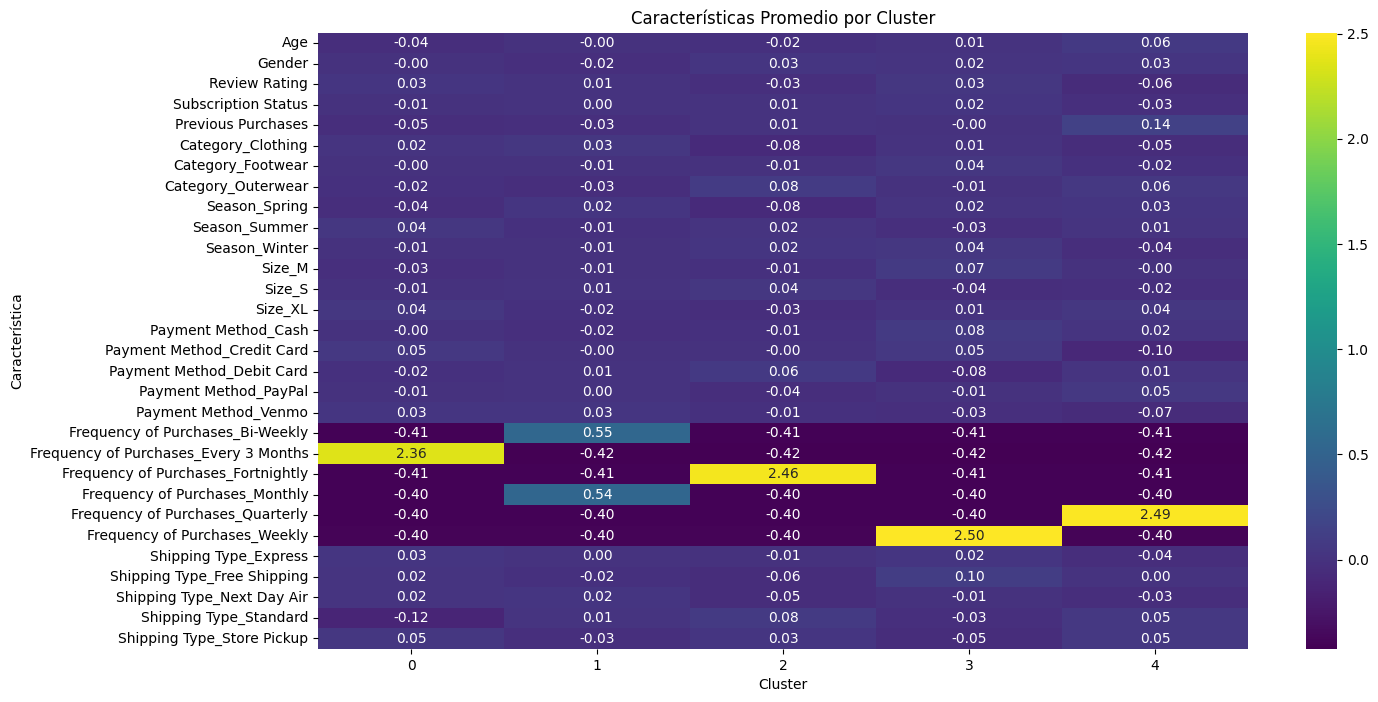

Distribución de 'Discount Applied' por Cluster:


Discount Applied,0,1
Cluster,,
0,0.564211,0.435789
1,0.588939,0.411061
2,0.565315,0.434685
3,0.564103,0.435897
4,0.580645,0.419355


In [37]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_clustering)

# Asignar las etiquetas de los clusters al DataFrame original procesado para su análisis
# nos aseguraremos de que el DataFrame al que adjuntamos las etiquetas tenga el mismo índice que X_clustering (X_train_clf_svc)
df_clustered = pd.DataFrame(X_train_scaled_clf_svc, columns=X_clf_svc.columns)
df_clustered['Cluster'] = cluster_labels

# Análisis de los clusters: calcular el promedio de las características para cada cluster
cluster_summary = df_clustered.groupby('Cluster').mean()

# Visualizar las características principales por cluster para una mejor interpretación

plt.figure(figsize=(15, 8))
sns.heatmap(cluster_summary.T, annot=True, cmap='viridis', fmt=".2f")
plt.title('Características Promedio por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Característica')
plt.show()

#distribución de la variable objetivo (Discount Applied) dentro de cada cluster
#fusionar las etiquetas de cluster con la variable objetivo real
df_train_with_target = pd.DataFrame(X_train_clf_svc, columns=X_clf_svc.columns)
df_train_with_target['Cluster'] = cluster_labels
df_train_with_target['Discount Applied'] = y_train_clf_svc.values


print("Distribución de 'Discount Applied' por Cluster:")
display(df_train_with_target.groupby('Cluster')['Discount Applied'].value_counts(normalize=True).unstack().fillna(0))


### Interpretación de los Clusters

En esta sección, describiremos los perfiles de cada cluster basándonos en las características promedio y la distribución de la variable objetivo dentro de cada uno.

Al observar la tabla de distribución de 'Discount Applied' por cluster, notamos que no hay una diferencia significativa en la proporción de descuentos aplicados entre los diferentes clusters. Todos los clusters muestran una proporción muy similar, donde aproximadamente el 56%-59% de las instancias no tuvieron descuento (Clase 0) y el 41%-44% sí tuvieron descuento (Clase 1)

* Cluster 0: 56.42% Sin Descuento, 43.58% Con Descuento
* Cluster 1: 58.89% Sin Descuento, 41.11% Con Descuento
* Cluster 2: 56.53% Sin Descuento, 43.47% Con Descuento
* Cluster 3: 56.41% Sin Descuento, 43.59% Con Descuento
* Cluster 4: 58.06% Sin Descuento, 41.94% Con Descuento

Esta distribución homogénea sugiere que las características utilizadas para el clustering (las mismas que para la clasificación, excluyendo Discount Applied y Promo Code Used) no logran segmentar a los clientes de manera que se diferencien significativamente en su propensión a recibir un descuento. En otras palabras, la agrupación en estos 5 clusters no revela grupos de clientes con una probabilidad intrínsecamente mayor o menor de tener un descuento aplicado.

###Posibles Razones:

* **Falta de Características Discriminatorias:** Las variables de entrada al K-Means (y previamente al SVC) podrían no contener la información necesaria para crear segmentos que estén fuertemente correlacionados con la aplicación de descuentos. Si el criterio para aplicar un descuento es aleatorio, externo a estas variables, o depende de interacciones muy complejas no capturadas, el clustering no podrá diferenciarlo.
* **La Variable 'Discount Applied' no es una Característica Intrínseca del Cliente:** Podría ser que la aplicación de un descuento sea más una decisión de marketing o una condición de la oferta que una característica inherente al tipo de cliente, por lo que las segmentaciones basadas en el comportamiento de compra o datos demográficos no se alinearían con ella.